In [11]:


import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers as L
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import random
import os

In [12]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        # Choose the GPU(s) you want to enable (e.g., gpus[1] for the second GPU)
        tf.config.set_visible_devices(gpus[0], 'GPU')
        # Once you set visible devices, you can also set memory growth if you want
        tf.config.experimental.set_memory_growth(gpus[0], True)
    except RuntimeError as e:
        # Visible devices must be set at program startup
        print(e)



Grabbing paths of imageset and splitting into training and testing

In [13]:
# Path to your folder of images
train_image_folder = "/home/dylan/SleepApnea/rotated_image"
# valid_image_folder = "/home/dylan/SleepApnea/validation/pngs/class1"
# Get all image paths
image_paths = [str(p) for p in Path(train_image_folder).glob("*.bmp")]  
# valid_paths = [str(p) for p in Path(valid_image_folder).glob("*.png")]  
image_paths = np.array(image_paths)  # Convert to NumPy array for shuffling
# valid_paths = np.array(valid_paths)
print(len(image_paths))
# Shuffle and split the dataset
np.random.shuffle(image_paths)

split_idx = int(0.8 * len(image_paths))  # 80% for training, 20% for validation


train_paths = image_paths[:split_idx]
valid_paths = image_paths[split_idx:]




700


In [14]:
def load_image(path):
    img = tf.io.read_file(path)  # Read the raw image file
    img = tf.image.decode_bmp(img, channels=3)  # Decode the image as RGB (3 channels)

    # # Trying some stuff
    # img = tf.io.read_file(path)  # Read the raw image file
    # img = tf.image.decode_png(img, channels=3)  # Decode the image as RGB (3 channels)

    # # Get image dimensions
    # height = tf.shape(img)[0]
    # width = tf.shape(img)[1]

    # # Calculate the starting coordinates for the center crop
    # crop_height, crop_width = (32, 32)
    # offset_height = (height - crop_height) // 2
    # offset_width = (width - crop_width) // 2

    # # Crop the center of the image
    # img_cropped = tf.image.crop_to_bounding_box(
    #     img, offset_height, offset_width, crop_height, crop_width
    # )

    # return img_cropped
    return img  # No resizing or normalization here


In [15]:
IMAGE_SIZE = 48  
PATCH_SIZE = 6
NUM_PATCHES = (IMAGE_SIZE // PATCH_SIZE) ** 2
MASK_PROPORTION = 0.30

BUFFER_SIZE = 1024
BATCH_SIZE = 8
INPUT_SHAPE = (32, 32, 3)
AUTO = tf.data.AUTOTUNE

In [16]:
def get_train_augmentation_model():
    model = keras.Sequential(
        [
            L.Rescaling(1 / 255.0),
            L.Resizing(INPUT_SHAPE[0] + 20, INPUT_SHAPE[0] + 20),
            L.RandomCrop(IMAGE_SIZE, IMAGE_SIZE),
            L.RandomFlip("horizontal"),
        ],
        name="train_data_augmentation",
    )
    return model


def get_test_augmentation_model():
    model = keras.Sequential(
        [L.Rescaling(1 / 255.0), L.Resizing(IMAGE_SIZE, IMAGE_SIZE),],
        name="test_data_augmentation",
    )
    return model


In [17]:
# (x_train, y_train), (x_valid, y_valid) = keras.datasets.cifar100.load_data()
print(f"Training samples: {len(train_paths)}")
print(f"Testing samples: {len(valid_paths)}")

# train_ds = tf.data.Dataset.from_tensor_slices(train_paths)
# train_ds = train_ds.shuffle(BUFFER_SIZE).batch(BATCH_SIZE).prefetch(AUTO)

# valid_ds = tf.data.Dataset.from_tensor_slices(x_valid)
# valid_ds = valid_ds.batch(BATCH_SIZE).prefetch(AUTO)



# Get augmentation models (train and test)
train_augmentation = get_train_augmentation_model()
test_augmentation = get_test_augmentation_model()

# Create a training dataset
train_ds = tf.data.Dataset.from_tensor_slices(train_paths)
train_ds = (
    train_ds.map(load_image, num_parallel_calls=AUTO)  # Load the raw images
    # .map(lambda x: train_augmentation(x), num_parallel_calls=AUTO)  # Apply train augmentation
    .shuffle(BUFFER_SIZE)  # Shuffle the dataset
    .batch(BATCH_SIZE)  # Batch the dataset
    .prefetch(AUTO)  # Prefetch for better performance
)

# Create a validation dataset
valid_ds = tf.data.Dataset.from_tensor_slices(valid_paths)
valid_ds = (
    valid_ds.map(load_image, num_parallel_calls=AUTO)  # Load the raw images
    # .map(lambda x: test_augmentation(x), num_parallel_calls=AUTO)  # Apply test augmentation
    .batch(BATCH_SIZE)  # Batch the dataset
    .prefetch(AUTO)  # Prefetch for better performance
)

Training samples: 560
Testing samples: 140


In [18]:
class Patches(L.Layer):
    def __init__(self, patch_size=PATCH_SIZE, **kwargs):
        super().__init__(**kwargs)
        self.patch_size = patch_size
        self.resize = L.Reshape((-1, patch_size * patch_size * 3))

    def call(self, images):
        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding="VALID",
        )
        patches = self.resize(patches)
        return patches

    def show_patched_image(self, images, patches):
        idx = np.random.choice(patches.shape[0])
        print(f"Index selected: {idx}.")

        plt.figure(figsize=(4, 4))
        plt.imshow(keras.utils.array_to_img(images[idx]))
        plt.suptitle('Original Image')
        plt.axis("off")
        plt.show()

        n = int(np.sqrt(patches.shape[1]))
        plt.figure(figsize=(4, 4))
        plt.suptitle('Patches')
        for i, patch in enumerate(patches[idx]):
            ax = plt.subplot(n, n, i + 1)
            patch_img = tf.reshape(patch, (self.patch_size, self.patch_size, 3))
            plt.imshow(keras.utils.img_to_array(patch_img))
            plt.axis("off")
        plt.show()

        return idx

    def reconstruct_from_patch(self, patch):
        num_patches = patch.shape[0]
        n = int(np.sqrt(num_patches))
        patch = tf.reshape(patch, (num_patches, self.patch_size, self.patch_size, 3))
        rows = tf.split(patch, n, axis=0)
        rows = [tf.concat(tf.unstack(x), axis=1) for x in rows]
        reconstructed = tf.concat(rows, axis=0)
        return reconstructed


Index selected: 5.


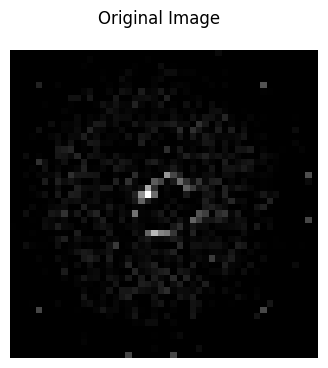

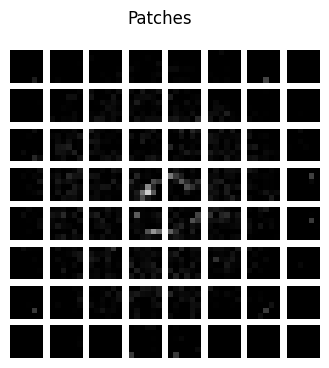

In [19]:
image_batch = next(iter(train_ds))

augmentation_model = get_train_augmentation_model()
augmented_images = augmentation_model(image_batch)

patch_layer = Patches()
patches = patch_layer(images=augmented_images)
random_index = patch_layer.show_patched_image(images=augmented_images, patches=patches)


In [20]:
LAYER_NORM_EPS = 1e-6
ENC_PROJECTION_DIM = 128
DEC_PROJECTION_DIM = 64
ENC_NUM_HEADS = 4
ENC_LAYERS = 6
DEC_NUM_HEADS = 4
DEC_LAYERS = (
    2 
)
ENC_TRANSFORMER_UNITS = [
    ENC_PROJECTION_DIM * 2,
    ENC_PROJECTION_DIM,
] 
DEC_TRANSFORMER_UNITS = [
    DEC_PROJECTION_DIM * 2,
    DEC_PROJECTION_DIM,
]

In [21]:
EPOCHS = 250
DOWNSTREAM_EPOCHS = 250

In [22]:
class PatchEncoder(L.Layer):
    def __init__(
        self,
        patch_size=PATCH_SIZE,
        projection_dim=ENC_PROJECTION_DIM,
        mask_proportion=MASK_PROPORTION,
        downstream=False,
        **kwargs,
    ):
        super().__init__(**kwargs)
        self.patch_size = patch_size
        self.projection_dim = projection_dim
        self.mask_proportion = mask_proportion
        self.downstream = downstream

        self.mask_token = tf.Variable(
            tf.random.normal([1, patch_size * patch_size * 3]), trainable=True
        )

    def build(self, input_shape):
        (_, self.num_patches, self.patch_area) = input_shape
        self.projection = L.Dense(units=self.projection_dim)
        self.position_embedding = L.Embedding(
            input_dim=self.num_patches, output_dim=self.projection_dim
        )
        self.num_mask = int(self.mask_proportion * self.num_patches)

    def call(self, patches):
        batch_size = tf.shape(patches)[0]
        positions = tf.range(start=0, limit=self.num_patches, delta=1)
        pos_embeddings = self.position_embedding(positions[tf.newaxis, ...])
        pos_embeddings = tf.tile(
            pos_embeddings, [batch_size, 1, 1]
        )
        patch_embeddings = (
            self.projection(patches) + pos_embeddings
        ) 
        if self.downstream:
            return patch_embeddings
        else:
            mask_indices, unmask_indices = self.get_random_indices(batch_size)
            unmasked_embeddings = tf.gather(
                patch_embeddings, unmask_indices, axis=1, batch_dims=1
            )
            unmasked_positions = tf.gather(
                pos_embeddings, unmask_indices, axis=1, batch_dims=1
            )
            masked_positions = tf.gather(
                pos_embeddings, mask_indices, axis=1, batch_dims=1
            ) 
            mask_tokens = tf.repeat(self.mask_token, repeats=self.num_mask, axis=0)
            mask_tokens = tf.repeat(
                mask_tokens[tf.newaxis, ...], repeats=batch_size, axis=0
            )

            masked_embeddings = self.projection(mask_tokens) + masked_positions
            return (
                unmasked_embeddings,
                masked_embeddings,
                unmasked_positions,
                mask_indices,
                unmask_indices,
            )

    def get_random_indices(self, batch_size):
        rand_indices = tf.argsort(
            tf.random.uniform(shape=(batch_size, self.num_patches)), axis=-1
        )
        mask_indices = rand_indices[:, : self.num_mask]
        unmask_indices = rand_indices[:, self.num_mask :]
        return mask_indices, unmask_indices

    def generate_masked_image(self, patches, unmask_indices):
        idx = np.random.choice(patches.shape[0])
        patch = patches[idx]
        unmask_index = unmask_indices[idx]
        new_patch = np.zeros_like(patch)
        count = 0
        for i in range(unmask_index.shape[0]):
            new_patch[unmask_index[i]] = patch[unmask_index[i]]
        return new_patch, idx

In [23]:
def dense_projection(x, dropout_rate, hidden_units):
    for units in hidden_units:
        x = L.Dense(units, activation=tf.nn.gelu)(x)
        x = L.Dropout(dropout_rate)(x)
    return x

In [24]:
def create_encoder(num_heads=ENC_NUM_HEADS, num_layers=ENC_LAYERS):
    inputs = L.Input((None, ENC_PROJECTION_DIM))
    x = inputs

    for _ in range(num_layers):
        x1 = L.LayerNormalization(epsilon=LAYER_NORM_EPS)(x)
        attention_output = L.MultiHeadAttention(
            num_heads=num_heads, key_dim=ENC_PROJECTION_DIM, dropout=0.1
        )(x1, x1)
        x2 = L.Add()([attention_output, x])
        x3 = L.LayerNormalization(epsilon=LAYER_NORM_EPS)(x2)
        x3 = dense_projection(x3, hidden_units=ENC_TRANSFORMER_UNITS, dropout_rate=0.1)
        x = L.Add()([x3, x2])

    outputs = L.LayerNormalization(epsilon=LAYER_NORM_EPS)(x)
    return keras.Model(inputs, outputs, name="mae_encoder")

In [25]:
def create_decoder(
    num_layers=DEC_LAYERS, num_heads=DEC_NUM_HEADS, image_size=IMAGE_SIZE
):
    inputs = L.Input((NUM_PATCHES, ENC_PROJECTION_DIM))
    x = L.Dense(DEC_PROJECTION_DIM)(inputs)

    for _ in range(num_layers):
        x1 = L.LayerNormalization(epsilon=LAYER_NORM_EPS)(x)
        attention_output = L.MultiHeadAttention(
            num_heads=num_heads, key_dim=DEC_PROJECTION_DIM, dropout=0.1
        )(x1, x1)
        x2 = L.Add()([attention_output, x])
        x3 = L.LayerNormalization(epsilon=LAYER_NORM_EPS)(x2)
        x3 = dense_projection(x3, hidden_units=DEC_TRANSFORMER_UNITS, dropout_rate=0.1)
        x = L.Add()([x3, x2])

    x = L.LayerNormalization(epsilon=LAYER_NORM_EPS)(x)
    x = L.Flatten()(x)
    pre_final = L.Dense(units=image_size * image_size * 3, activation="sigmoid")(x)
    outputs = L.Reshape((image_size, image_size, 3))(pre_final)

    return keras.Model(inputs, outputs, name="mae_decoder")

In [26]:
class MaskedAutoencoder(keras.Model):
    def __init__(
        self,
        train_augmentation_model,
        test_augmentation_model,
        patch_layer,
        patch_encoder,
        encoder,
        decoder,
        **kwargs,
    ):
        super().__init__(**kwargs)
        self.train_augmentation_model = train_augmentation_model
        self.test_augmentation_model = test_augmentation_model
        self.patch_layer = patch_layer
        self.patch_encoder = patch_encoder
        self.encoder = encoder
        self.decoder = decoder

    def calculate_loss(self, images, test=False):
        if test:
            augmented_images = self.test_augmentation_model(images)
        else:
            augmented_images = self.train_augmentation_model(images)

        patches = self.patch_layer(augmented_images)
        (
            unmasked_embeddings,
            masked_embeddings,
            unmasked_positions,
            mask_indices,
            unmask_indices,
        ) = self.patch_encoder(patches)

        encoder_outputs = self.encoder(unmasked_embeddings)
        encoder_outputs = encoder_outputs + unmasked_positions
        decoder_inputs = tf.concat([encoder_outputs, masked_embeddings], axis=1)
        decoder_outputs = self.decoder(decoder_inputs)
        decoder_patches = self.patch_layer(decoder_outputs)

        loss_patch = tf.gather(patches, mask_indices, axis=1, batch_dims=1)
        loss_output = tf.gather(decoder_patches, mask_indices, axis=1, batch_dims=1)

        total_loss = self.compiled_loss(loss_patch, loss_output)

        return total_loss, loss_patch, loss_output

    def train_step(self, images):
        with tf.GradientTape() as tape:
            total_loss, loss_patch, loss_output = self.calculate_loss(images)

        train_vars = [
            self.train_augmentation_model.trainable_variables,
            self.patch_layer.trainable_variables,
            self.patch_encoder.trainable_variables,
            self.encoder.trainable_variables,
            self.decoder.trainable_variables,
        ]
        grads = tape.gradient(total_loss, train_vars)
        tv_list = []
        for (grad, var) in zip(grads, train_vars):
            for g, v in zip(grad, var):
                tv_list.append((g, v))
        self.optimizer.apply_gradients(tv_list)
        self.compiled_metrics.update_state(loss_patch, loss_output)
        return {m.name: m.result() for m in self.metrics}

    def test_step(self, images):
        total_loss, loss_patch, loss_output = self.calculate_loss(images, test=True)
        self.compiled_metrics.update_state(loss_patch, loss_output)
        return {m.name: m.result() for m in self.metrics}

In [27]:
test_images = next(iter(valid_ds))


class TrainMonitor(keras.callbacks.Callback):
    def __init__(self, epoch_interval=None):
        self.epoch_interval = epoch_interval

    def on_epoch_end(self, epoch, logs=None):
        if self.epoch_interval and epoch % self.epoch_interval == 0:
            test_augmented_images = self.model.test_augmentation_model(test_images)
            test_patches = self.model.patch_layer(test_augmented_images)
            (
                test_unmasked_embeddings,
                test_masked_embeddings,
                test_unmasked_positions,
                test_mask_indices,
                test_unmask_indices,
            ) = self.model.patch_encoder(test_patches)
            test_encoder_outputs = self.model.encoder(test_unmasked_embeddings)
            test_encoder_outputs = test_encoder_outputs + test_unmasked_positions
            test_decoder_inputs = tf.concat(
                [test_encoder_outputs, test_masked_embeddings], axis=1
            )
            test_decoder_outputs = self.model.decoder(test_decoder_inputs)

            # Show a maksed patch image.
            test_masked_patch, idx = self.model.patch_encoder.generate_masked_image(
                test_patches, test_unmask_indices
            )
            print(f"\nIdx chosen: {idx}")
            original_image = test_augmented_images[idx]
            masked_image = self.model.patch_layer.reconstruct_from_patch(
                test_masked_patch
            )
            reconstructed_image = test_decoder_outputs[idx]

            fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))
            ax[0].imshow(original_image)
            ax[0].set_title(f"Original: {epoch:03d}")

            ax[1].imshow(masked_image)
            ax[1].set_title(f"Masked: {epoch:03d}")

            ax[2].imshow(reconstructed_image)
            ax[2].set_title(f"Resonstructed: {epoch:03d}")

            plt.show()
            plt.close()

In [28]:

train_augmentation_model = get_train_augmentation_model()
test_augmentation_model = get_test_augmentation_model()
patch_layer = Patches()
patch_encoder = PatchEncoder()
encoder = create_encoder()
decoder = create_decoder()

mae_model = MaskedAutoencoder(
    train_augmentation_model=train_augmentation_model,
    test_augmentation_model=test_augmentation_model,
    patch_layer=patch_layer,
    patch_encoder=patch_encoder,
    encoder=encoder,
    decoder=decoder,
)


mae_model.compile(
    optimizer='adam', loss=keras.losses.MeanSquaredError(), metrics=["mae"]
)

Epoch 1/250


/home/dylan/.local/lib/python3.10/site-packages/keras/src/backend/tensorflow/trainer.py:664: UserWarning: `model.compiled_loss()` is deprecated. Instead, use `model.compute_loss(x, y, y_pred, sample_weight, training)`.
  warnings.warn(
/home/dylan/.local/lib/python3.10/site-packages/keras/src/backend/tensorflow/trainer.py:639: UserWarning: `model.compiled_metrics()` is deprecated. Instead, use e.g.:
```
for metric in self.metrics:
    metric.update_state(y, y_pred)
```

  return self._compiled_metrics_update_state(


70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - mae: 0.0645 - loss: 0.0512
Idx chosen: 1


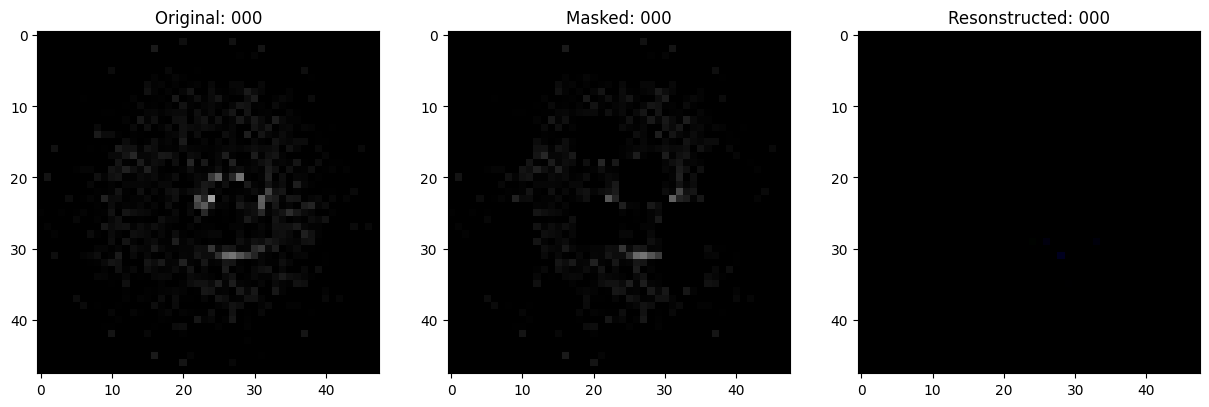

70/70 ━━━━━━━━━━━━━━━━━━━━ 19s 102ms/step - mae: 0.0638 - loss: 0.0506 - val_loss: 4.3038e-05 - learning_rate: 0.0010
Epoch 2/250
70/70 ━━━━━━━━━━━━━━━━━━━━ 5s 67ms/step - mae: 0.0182 - loss: 4.1657e-05 - val_loss: 5.2046e-05 - learning_rate: 0.0010
Epoch 3/250
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - mae: 0.0185 - loss: 3.5387e-05
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.
70/70 ━━━━━━━━━━━━━━━━━━━━ 5s 66ms/step - mae: 0.0184 - loss: 3.5275e-05 - val_loss: 3.4691e-05 - learning_rate: 0.0010
Epoch 4/250
70/70 ━━━━━━━━━━━━━━━━━━━━ 5s 66ms/step - mae: 0.0188 - loss: 3.4641e-05 - val_loss: 4.5756e-05 - learning_rate: 1.0000e-04
Epoch 5/250
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - mae: 0.0186 - loss: 5.1243e-05
Epoch 5: ReduceLROnPlateau reducing learning rate to 1.0000000474974514e-05.
70/70 ━━━━━━━━━━━━━━━━━━━━ 5s 66ms/step - mae: 0.0185 - loss: 5.1248e-05 - val_loss: 5.1061e-05 - learning_rate: 1.0000e-04
Epoch 6/250
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms

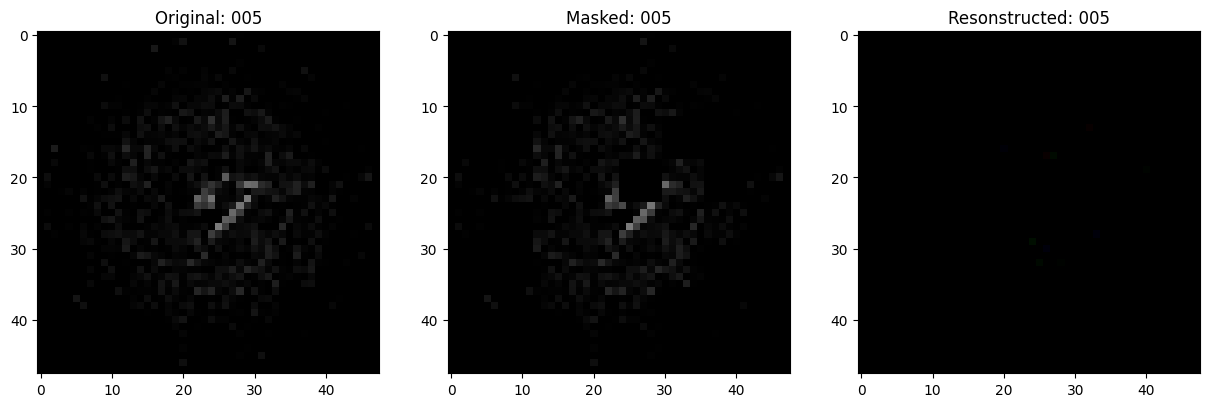

70/70 ━━━━━━━━━━━━━━━━━━━━ 5s 70ms/step - mae: 0.0185 - loss: 5.1242e-05 - val_loss: 5.2467e-05 - learning_rate: 1.0000e-05
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 1.
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - mae: 0.0156 - loss: 4.1040e-05
Loss: 0.00
MAE: {'mae': <tf.Tensor: shape=(), dtype=float32, numpy=0.015754207968711853>}


In [29]:
es = keras.callbacks.EarlyStopping(min_delta=1e-4, patience=5, verbose=1, restore_best_weights=True)
rlp = keras.callbacks.ReduceLROnPlateau(patience=2, verbose=1)

history = mae_model.fit(
    train_ds, epochs=EPOCHS, validation_data=valid_ds, callbacks=[TrainMonitor(epoch_interval=5), es, rlp],
)

loss, mae = mae_model.evaluate(valid_ds)
print(f"Loss: {loss:.2f}")
print(f"MAE: {mae}")

In [30]:

train_augmentation_model = mae_model.train_augmentation_model
test_augmentation_model = mae_model.test_augmentation_model

patch_layer = mae_model.patch_layer
patch_encoder = mae_model.patch_encoder
patch_encoder.downstream = True

encoder = mae_model.encoder

downstream_model = keras.Sequential(
    [
        L.Input((IMAGE_SIZE, IMAGE_SIZE, 3)),
        patch_layer,
        patch_encoder,
        encoder,
        L.BatchNormalization(),
        L.GlobalAveragePooling1D(),
        L.Dense(10, activation="softmax"),
    ],
    name="downstream_model",
)

In [31]:
def prepare_data(images, labels, is_train=True):
    if is_train:
        augmentation_model = train_augmentation_model
    else:
        augmentation_model = test_augmentation_model

    dataset = tf.data.Dataset.from_tensor_slices((images, labels))
    if is_train:
        dataset = dataset.shuffle(BUFFER_SIZE)

    dataset = dataset.batch(BATCH_SIZE).map(
        lambda x, y: (augmentation_model(x), y), num_parallel_calls=AUTO
    )
    return dataset.prefetch(AUTO)

(x_train, y_train), (x_valid, y_valid) = keras.datasets.cifar10.load_data()
train_ds = prepare_data(x_train, y_train)
valid_ds = prepare_data(x_valid, y_valid, is_train=False)

In [32]:
downstream_model.compile(
    optimizer='adam', loss="sparse_categorical_crossentropy", metrics=["accuracy"]
)

es = keras.callbacks.EarlyStopping(min_delta=1e-4, patience=5, verbose=1, restore_best_weights=True)
rlp = keras.callbacks.ReduceLROnPlateau(patience=2, verbose=1)

downstream_model.fit(train_ds, validation_data=valid_ds, epochs=DOWNSTREAM_EPOCHS, callbacks=[es, rlp])

loss, accuracy = downstream_model.evaluate(valid_ds)
accuracy = round(accuracy * 100, 2)
print(f"Accuracy on the test set: {accuracy}%.")

Epoch 1/250


I0000 00:00:1734476382.174972  924388 service.cc:148] XLA service 0x790b2c007010 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1734476382.174995  924388 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 4090, Compute Capability 8.9
2024-12-17 14:59:42.397962: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1734476383.412292  924388 cuda_dnn.cc:529] Loaded cuDNN version 90600
2024-12-17 14:59:45.453928: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_41', 4 bytes spill stores, 4 bytes spill loads

2024-12-17 14:59:45.468759: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_80', 76 bytes spill

  25/6250 ━━━━━━━━━━━━━━━━━━━━ 41s 7ms/step - accuracy: 0.1834 - loss: 2.2477       

I0000 00:00:1734476392.377937  924388 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


6243/6250 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2777 - loss: 1.9416

2024-12-17 15:00:35.247149: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_56', 8 bytes spill stores, 8 bytes spill loads



6250/6250 ━━━━━━━━━━━━━━━━━━━━ 65s 8ms/step - accuracy: 0.2777 - loss: 1.9416 - val_accuracy: 0.2362 - val_loss: 2.0476 - learning_rate: 0.0010
Epoch 2/250
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 44s 7ms/step - accuracy: 0.2537 - loss: 2.0173 - val_accuracy: 0.1807 - val_loss: 2.2813 - learning_rate: 0.0010
Epoch 3/250
6244/6250 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2510 - loss: 2.0135
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 44s 7ms/step - accuracy: 0.2510 - loss: 2.0135 - val_accuracy: 0.2310 - val_loss: 2.1353 - learning_rate: 0.0010
Epoch 4/250
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 44s 7ms/step - accuracy: 0.2862 - loss: 1.9372 - val_accuracy: 0.2963 - val_loss: 1.8832 - learning_rate: 1.0000e-04
Epoch 5/250
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 44s 7ms/step - accuracy: 0.2985 - loss: 1.9090 - val_accuracy: 0.3037 - val_loss: 1.8684 - learning_rate: 1.0000e-04
Epoch 6/250
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 43s 7ms/step - accuracy: 0.